# MERT + Projection Head Fine-tuning (Option 1)
## Frozen MERT Encoder → Trainable MLP Projection → Triplet Loss

**Idea:** MERT's 768-dim features are rich but not tuned for melody retrieval.  
A small trainable projection head learns to map them into a retrieval-optimised 128-dim space.

```
MIDI ──► WAV ──► MERT (frozen, 95M params) ──► 768-dim chunk embeddings
                                                       │  cached to disk
                                                       ▼
                              ProjectionHead (trainable, ~200K params)
                              Linear(768→256) → LayerNorm → ReLU → Dropout
                              → Linear(256→128) → L2-norm
                                                       │
                                                TripletLoss + Hard Mining
```

**Two-stage training:**
1. Pre-compute MERT chunk features for all corpus files → cache to disk (~30-60 min, runs once)
2. Train projection head on cached features → fast (~5-10 min)

**Results compared against:**
- SiameseCNN v1 (64% Top-1)
- MERT zero-shot (from `mert_evaluation.ipynb`)

## 0. Imports & Config

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import soundfile as sf
import json
import subprocess
import tempfile
import os
import random
from pathlib import Path
from collections import defaultdict
from math import gcd
from scipy.signal import resample_poly
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoProcessor

from src.data_pipeline import MIDIDataset
from src.siamese_network import TripletLoss, HardNegativeMiner

# ── Paths ──────────────────────────────────────────────────────────────────
CORPUS_DIR    = '../capstone_team_3/MidiDatasets/590-Classical-music-midi'
MIDI_TEST_DIR = '../capstone_team_3/MidiDatasets/TestingSamples/MidiOutputs'
CSV_PATH      = '../capstone_team_3/MidiDatasets/TestingSamples/TestingReferences.csv'
MERT_CACHE    = Path('../checkpoints/mert')                  # mean-pool cache from mert_evaluation
CHUNK_CACHE   = Path('../checkpoints/mert_finetuned/chunks') # per-chunk features (new)
OUT_DIR       = Path('../checkpoints/mert_finetuned')
SF2_PATH      = next(Path('/').rglob('TimGM6mb.sf2'), None)
V1_RESULTS    = Path('../checkpoints/baseline1/external_test_results.json')
MERT_EXT_RES  = Path('../checkpoints/mert/external_test_results.json')

CHUNK_CACHE.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyper-parameters ───────────────────────────────────────────────────────
MERT_MODEL   = 'm-a-p/MERT-v1-95M'
TARGET_SR    = 24000
MAX_AUDIO_S  = 30          # seconds per MERT chunk
HIDDEN_DIM   = 256         # projection head hidden size
EMBED_DIM    = 128         # output embedding size
DROPOUT      = 0.2
BATCH_SIZE   = 32
LR           = 1e-3
NUM_EPOCHS   = 30
MARGIN       = 0.2
MINING       = 'semi-hard'
RANDOM_SEED  = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                       'cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device       : {device}')
print(f'MERT model   : {MERT_MODEL}')
print(f'Projection   : 768 → {HIDDEN_DIM} → {EMBED_DIM}')
print(f'Chunk length : {MAX_AUDIO_S}s  |  Batch: {BATCH_SIZE}  |  Epochs: {NUM_EPOCHS}')
assert SF2_PATH, 'SoundFont not found — install pretty_midi'

Device       : mps
MERT model   : m-a-p/MERT-v1-95M
Projection   : 768 → 256 → 128
Chunk length : 30s  |  Batch: 32  |  Epochs: 30


## 1. Load MERT (Frozen)

In [2]:
print(f'Loading {MERT_MODEL} (frozen encoder)...')
processor  = AutoProcessor.from_pretrained(MERT_MODEL, trust_remote_code=True)
mert_model = AutoModel.from_pretrained(MERT_MODEL, trust_remote_code=True)
mert_model = mert_model.to(device)
mert_model.eval()

# Freeze all MERT parameters
for p in mert_model.parameters():
    p.requires_grad = False

mert_params     = sum(p.numel() for p in mert_model.parameters())
mert_trainable  = sum(p.numel() for p in mert_model.parameters() if p.requires_grad)
print(f'MERT params  : {mert_params:,}  (trainable: {mert_trainable})')
print(f'MERT frozen  : ✓')

Loading m-a-p/MERT-v1-95M (frozen encoder)...


The image processor of type `Wav2Vec2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

MERT params  : 94,371,712  (trainable: 0)
MERT frozen  : ✓


## 2. Projection Head Architecture

In [3]:
class ProjectionHead(nn.Module):
    """
    Maps frozen MERT 768-dim features → 128-dim retrieval embedding.

    Linear(768→256) → LayerNorm → ReLU → Dropout
    → Linear(256→128) → L2-norm
    """
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (batch, 768) → (batch, 128) L2-normalised."""
        return F.normalize(self.net(x), p=2, dim=1)


proj_head = ProjectionHead(
    input_dim  = mert_model.config.hidden_size,  # 768
    hidden_dim = HIDDEN_DIM,
    output_dim = EMBED_DIM,
    dropout    = DROPOUT
).to(device)

proj_params = sum(p.numel() for p in proj_head.parameters())
print(f'ProjectionHead params : {proj_params:,}  (all trainable)')
print(f'Ratio to MERT         : {proj_params/mert_params:.2%}')
print(proj_head)

ProjectionHead params : 230,272  (all trainable)
Ratio to MERT         : 0.24%
ProjectionHead(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
  )
)


## 3. MIDI → Per-Chunk MERT Features

Extracts and caches **per-chunk** 768-dim MERT features for every corpus file.  
Unlike `mert_evaluation.ipynb` (which cached one mean-pooled vector per file), this stores  
all chunks separately to give the projection head more training samples.

> **Cached** in `checkpoints/mert_finetuned/chunks/` — runs once (~30–60 min).

In [4]:
def resample_audio(audio, orig_sr, target_sr):
    if orig_sr == target_sr:
        return audio.astype(np.float32)
    g = gcd(orig_sr, target_sr)
    return resample_poly(audio, target_sr // g, orig_sr // g).astype(np.float32)


@torch.no_grad()
def audio_to_chunks(audio: np.ndarray, sr: int) -> list[torch.Tensor]:
    """Split audio into MAX_AUDIO_S chunks, return list of 768-dim MERT embeddings."""
    audio    = resample_audio(audio, sr, TARGET_SR)
    chunk_n  = MAX_AUDIO_S * TARGET_SR
    if len(audio) < chunk_n:
        audio = np.pad(audio, (0, chunk_n - len(audio)))

    chunks_emb = []
    for start in range(0, len(audio), chunk_n):
        seg = audio[start : start + chunk_n]
        if len(seg) < TARGET_SR:   # skip < 1s tail
            break
        if len(seg) < chunk_n:
            seg = np.pad(seg, (0, chunk_n - len(seg)))
        inp = processor(seg, sampling_rate=TARGET_SR, return_tensors='pt')
        inp = {k: v.to(device) for k, v in inp.items()}
        out = mert_model(**inp, output_hidden_states=True)
        emb = out.last_hidden_state.mean(dim=1).squeeze(0).cpu()   # (768,)
        chunks_emb.append(emb)
    return chunks_emb


def midi_to_wav(midi_path, wav_path):
    r = subprocess.run(
        ['fluidsynth', '-ni', '-F', wav_path, '-T', 'wav', str(SF2_PATH), str(midi_path)],
        capture_output=True, timeout=60
    )
    return r.returncode == 0 and Path(wav_path).exists()


def get_chunk_features(midi_path: Path, cache_key: str) -> list[torch.Tensor] | None:
    """Return per-chunk MERT features, loading from cache if available."""
    cache_file = CHUNK_CACHE / f'{cache_key}.pt'
    if cache_file.exists():
        return torch.load(cache_file, weights_only=True)  # list of (768,) tensors

    with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
        wav_path = tmp.name
    try:
        if not midi_to_wav(midi_path, wav_path):
            return None
        audio, sr = sf.read(wav_path)
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        chunks = audio_to_chunks(audio.astype(np.float32), sr)
        if chunks:
            torch.save(chunks, cache_file)
        return chunks if chunks else None
    except Exception as e:
        print(f'  Error {midi_path.name}: {e}')
        return None
    finally:
        if os.path.exists(wav_path):
            os.unlink(wav_path)


# ── Pre-compute for all corpus files ──
dataset      = MIDIDataset(CORPUS_DIR, random_seed=RANDOM_SEED)
corpus_files = dataset.midi_files
stem_to_idx  = {f.name.lower(): i for i, f in enumerate(corpus_files)}

print(f'Corpus  : {len(corpus_files)} files')
print(f'Train   : {len(dataset.train_files)}  Val: {len(dataset.val_files)}  Test: {len(dataset.test_files)}')
print(f'\nPre-computing per-chunk MERT features...')
print(f'(Loads from cache in CHUNK_CACHE if already computed)')

all_chunk_features = []   # list of lists: [[chunk_emb, ...], ...] per corpus file
n_total_chunks     = 0
failed_files       = []

for i, midi_path in enumerate(tqdm(corpus_files, desc='Extracting')):
    key    = f'{i:04d}_{midi_path.stem}'
    chunks = get_chunk_features(midi_path, key)
    if chunks is None or len(chunks) == 0:
        chunks = [torch.zeros(mert_model.config.hidden_size)]
        failed_files.append(midi_path.name)
    all_chunk_features.append(chunks)
    n_total_chunks += len(chunks)

print(f'\nTotal chunks : {n_total_chunks}  (~{n_total_chunks/len(corpus_files):.1f} per file)')
print(f'Failed       : {len(failed_files)}')

Loaded 292 MIDI files from ../capstone_team_3/MidiDatasets/590-Classical-music-midi
Split sizes - Train: 233, Val: 29, Test: 30
Creating split version: v1.0_classical_midi
Saved data version v1.0_classical_midi to data/versions/v1.0_classical_midi_split.json
Corpus  : 292 files
Train   : 233  Val: 29  Test: 30

Pre-computing per-chunk MERT features...
(Loads from cache in CHUNK_CACHE if already computed)


Extracting:   0%|          | 0/292 [00:00<?, ?it/s]


Total chunks : 2646  (~9.1 per file)
Failed       : 0


## 4. Training Dataset

In [5]:
class MERTChunkDataset(Dataset):
    """
    Each item: (768-dim MERT chunk feature, file-level label).
    Used for in-batch hard negative triplet mining.
    """
    def __init__(self, file_list, all_chunk_features, corpus_files):
        self.samples = []   # (feature_tensor, label)
        self.label_to_indices = defaultdict(list)

        file_to_label = {f: i for i, f in enumerate(corpus_files)}

        for midi_path in file_list:
            corpus_idx = file_to_label[midi_path]
            chunks     = all_chunk_features[corpus_idx]
            for chunk in chunks:
                idx = len(self.samples)
                self.samples.append((chunk, corpus_idx))
                self.label_to_indices[corpus_idx].append(idx)

        self.unique_labels = list(self.label_to_indices.keys())

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        feat, label = self.samples[idx]
        return feat.float(), label


# Build train / val datasets
train_dataset = MERTChunkDataset(dataset.train_files, all_chunk_features, corpus_files)
val_dataset   = MERTChunkDataset(dataset.val_files,   all_chunk_features, corpus_files)

print(f'Train dataset: {len(train_dataset)} chunks  ({len(dataset.train_files)} files)')
print(f'Val dataset  : {len(val_dataset)} chunks  ({len(dataset.val_files)} files)')
print(f'Chunks/file  : {len(train_dataset)/len(dataset.train_files):.1f} avg')

# Balanced sampler: ensure each batch contains multiple chunks per label
class BalancedBatchSampler:
    """Samples labels_per_batch labels, chunks_per_label chunks each."""
    def __init__(self, dataset, batch_size, chunks_per_label=2):
        self.dataset          = dataset
        self.chunks_per_label = chunks_per_label
        self.labels_per_batch = batch_size // chunks_per_label

    def __iter__(self):
        labels = self.dataset.unique_labels.copy()
        random.shuffle(labels)
        batch  = []
        for lbl in labels:
            indices = self.dataset.label_to_indices[lbl]
            batch  += random.choices(indices, k=self.chunks_per_label)
            if len(batch) >= self.labels_per_batch * self.chunks_per_label:
                yield batch[:self.labels_per_batch * self.chunks_per_label]
                batch = []
        if batch:
            yield batch

    def __len__(self):
        return len(self.dataset.unique_labels) // self.labels_per_batch


train_sampler = BalancedBatchSampler(train_dataset, BATCH_SIZE, chunks_per_label=2)
train_loader  = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Train dataset: 2162 chunks  (233 files)
Val dataset  : 232 chunks  (29 files)
Chunks/file  : 9.3 avg
Train batches: 14  Val batches: 8


## 5. Validation Helper

In [6]:
@torch.no_grad()
def evaluate_retrieval(proj: ProjectionHead,
                       query_dataset: MERTChunkDataset,
                       db_dataset:    MERTChunkDataset,
                       k_values=(1, 3, 5)) -> dict:
    """
    Build file-level embeddings (mean-pool projected chunks), then
    evaluate retrieval: for each query file, rank db files by cosine sim.
    """
    proj.eval()

    def file_embeddings(ds):
        # Group chunks by label, project, mean-pool
        label_chunks = defaultdict(list)
        for feat, label in ds.samples:
            label_chunks[label].append(feat.float().to(device))
        embs, labels = [], []
        for lbl, chunks in label_chunks.items():
            batch = torch.stack(chunks)          # (n_chunks, 768)
            proj_embs = proj(batch)              # (n_chunks, 128)
            mean_emb  = F.normalize(proj_embs.mean(0), p=2, dim=0)
            embs.append(mean_emb.cpu())
            labels.append(lbl)
        return torch.stack(embs), labels

    db_embs,    db_labels    = file_embeddings(db_dataset)
    query_embs, query_labels = file_embeddings(query_dataset)

    db_lbl_set = set(db_labels)
    sim = torch.mm(query_embs, db_embs.t())   # (n_query_files, n_db_files)

    correct_at_k = {k: 0 for k in k_values}
    rr_list = []
    for i, qlbl in enumerate(query_labels):
        if qlbl not in db_lbl_set:
            continue
        true_db_idx = db_labels.index(qlbl)
        order       = sim[i].argsort(descending=True).tolist()
        rank        = order.index(true_db_idx) + 1
        rr_list.append(1.0 / rank)
        for k in k_values:
            if rank <= k:
                correct_at_k[k] += 1

    n = len(rr_list)
    metrics = {f'top{k}_accuracy': correct_at_k[k] / n for k in k_values}
    metrics['mrr'] = float(np.mean(rr_list))
    return metrics

## 6. Training Loop

In [7]:
criterion  = TripletLoss(margin=MARGIN)
miner      = HardNegativeMiner(strategy=MINING)
optimizer  = optim.Adam(proj_head.parameters(), lr=LR)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

history = {'train_loss': [], 'train_active': [],
           'val_top1': [], 'val_top3': [], 'val_mrr': []}
best_val_top1 = 0.0

print(f'Training projection head for {NUM_EPOCHS} epochs...')
print(f'Optimizer : Adam (lr={LR})  Scheduler: CosineAnnealing')
print(f'Loss      : TripletLoss (margin={MARGIN})  Mining: {MINING}')
print('=' * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    proj_head.train()
    total_loss, total_active, n_batches = 0.0, 0, 0

    for feats, labels in train_loader:
        feats  = feats.to(device)
        labels = labels.to(device)

        embeddings = proj_head(feats)                        # (B, 128)
        anchors, positives, negatives = miner.mine_triplets(embeddings, labels)
        if anchors is None:
            continue

        loss, metrics = criterion(anchors, positives, negatives)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss   += loss.item()
        total_active += metrics['num_active_triplets']
        n_batches    += 1

    scheduler.step()
    avg_loss   = total_loss   / max(n_batches, 1)
    avg_active = total_active / max(n_batches, 1)

    # Validate every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        val_metrics = evaluate_retrieval(proj_head, val_dataset, val_dataset)
        history['val_top1'].append(val_metrics['top1_accuracy'])
        history['val_top3'].append(val_metrics['top3_accuracy'])
        history['val_mrr'].append(val_metrics['mrr'])

        print(f'Ep {epoch:>3}/{NUM_EPOCHS}  loss={avg_loss:.4f}  '
              f'active={avg_active:.1f}  '
              f'val Top-1={val_metrics["top1_accuracy"]:.4f}  '
              f'MRR={val_metrics["mrr"]:.4f}')

        if val_metrics['top1_accuracy'] > best_val_top1:
            best_val_top1 = val_metrics['top1_accuracy']
            torch.save({'epoch': epoch,
                        'proj_state_dict': proj_head.state_dict(),
                        'val_metrics': val_metrics,
                        'config': {'hidden_dim': HIDDEN_DIM, 'embed_dim': EMBED_DIM,
                                   'dropout': DROPOUT, 'mert_model': MERT_MODEL,
                                   'mert_hidden': mert_model.config.hidden_size}},
                       OUT_DIR / 'best_model.pt')
            print(f'  ✓ New best saved (Top-1: {best_val_top1:.4f})')
    else:
        history['val_top1'].append(history['val_top1'][-1] if history['val_top1'] else 0)
        history['val_top3'].append(history['val_top3'][-1] if history['val_top3'] else 0)
        history['val_mrr'].append(history['val_mrr'][-1]   if history['val_mrr']   else 0)

    history['train_loss'].append(avg_loss)
    history['train_active'].append(avg_active)

with open(OUT_DIR / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f'\nTraining complete. Best val Top-1: {best_val_top1:.4f}')

Training projection head for 30 epochs...
Optimizer : Adam (lr=0.001)  Scheduler: CosineAnnealing
Loss      : TripletLoss (margin=0.2)  Mining: semi-hard
Ep   1/30  loss=0.1125  active=21.8  val Top-1=1.0000  MRR=1.0000
  ✓ New best saved (Top-1: 1.0000)
Ep   5/30  loss=0.0314  active=8.9  val Top-1=1.0000  MRR=1.0000
Ep  10/30  loss=0.0475  active=10.1  val Top-1=1.0000  MRR=1.0000
Ep  15/30  loss=0.0260  active=6.1  val Top-1=1.0000  MRR=1.0000
Ep  20/30  loss=0.0182  active=5.5  val Top-1=1.0000  MRR=1.0000
Ep  25/30  loss=0.0228  active=4.7  val Top-1=1.0000  MRR=1.0000
Ep  30/30  loss=0.0164  active=5.1  val Top-1=1.0000  MRR=1.0000

Training complete. Best val Top-1: 1.0000


## 7. Training Curves

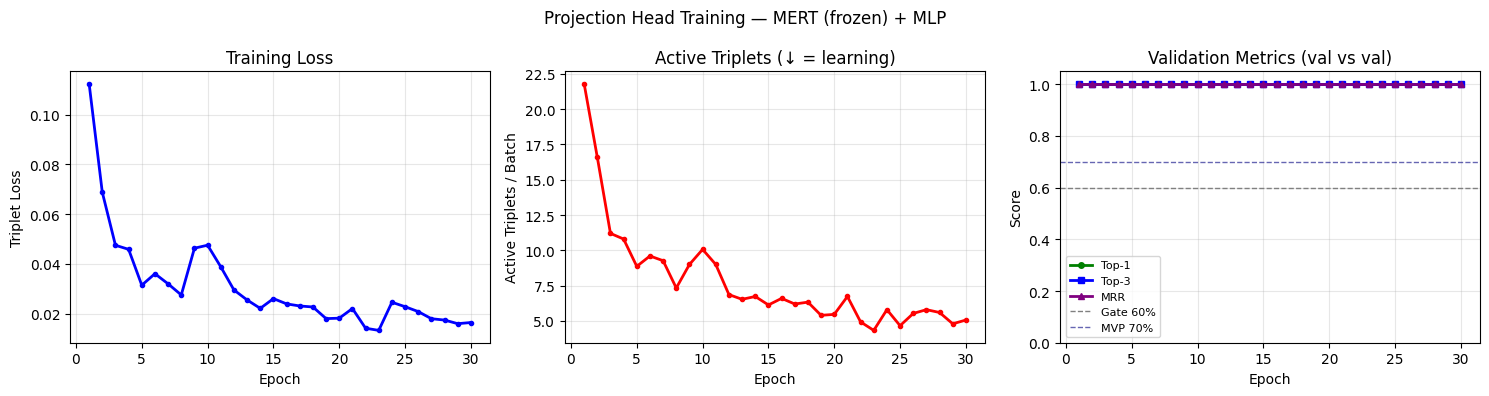

In [8]:
epochs = list(range(1, NUM_EPOCHS + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Projection Head Training — MERT (frozen) + MLP', fontsize=12)

axes[0].plot(epochs, history['train_loss'], 'b-o', ms=3, lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Triplet Loss')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_active'], 'r-o', ms=3, lw=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Active Triplets / Batch')
axes[1].set_title('Active Triplets (↓ = learning)'); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['val_top1'], 'g-o', ms=4, lw=2, label='Top-1')
axes[2].plot(epochs, history['val_top3'], 'b-s', ms=4, lw=2, label='Top-3')
axes[2].plot(epochs, history['val_mrr'],  'purple', marker='^', ms=4, lw=2, label='MRR')
axes[2].axhline(0.60, color='gray', ls='--', lw=1, label='Gate 60%')
axes[2].axhline(0.70, color='navy', ls='--', lw=1, alpha=0.6, label='MVP 70%')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
axes[2].set_title('Validation Metrics (val vs val)')
axes[2].set_ylim(0, 1.05); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Load Best Checkpoint & Build Corpus Embeddings

In [9]:
ckpt = torch.load(OUT_DIR / 'best_model.pt', weights_only=False)
proj_head.load_state_dict(ckpt['proj_state_dict'])
proj_head.eval()
print(f'Best checkpoint: epoch {ckpt["epoch"]}  '
      f'val Top-1={ckpt["val_metrics"]["top1_accuracy"]:.4f}')


@torch.no_grad()
def file_embedding(corpus_idx: int) -> torch.Tensor:
    """Project + mean-pool all chunks for a corpus file → L2-normed 128-dim."""
    chunks    = all_chunk_features[corpus_idx]
    batch     = torch.stack([c.float() for c in chunks]).to(device)
    proj_embs = proj_head(batch)                             # (n, 128)
    mean_emb  = F.normalize(proj_embs.mean(0), p=2, dim=0)
    return mean_emb.cpu()


print('Building projected corpus embeddings...')
corpus_proj_embs = torch.stack([
    file_embedding(i) for i in tqdm(range(len(corpus_files)), desc='Corpus')
])   # (590, 128)

print(f'Corpus embedding matrix: {corpus_proj_embs.shape}')

Best checkpoint: epoch 1  val Top-1=1.0000
Building projected corpus embeddings...


Corpus:   0%|          | 0/292 [00:00<?, ?it/s]

Corpus embedding matrix: torch.Size([292, 128])


## 9. External Test Set Evaluation

In [10]:
df_raw = pd.read_csv(CSV_PATH)
df     = df_raw[df_raw['FullTestPath'].str.lower().str.contains('midioutputs')].copy().reset_index(drop=True)
df['midi_path']      = df['FullTestPath'].apply(lambda x: Path(MIDI_TEST_DIR) / x.split('midioutputs/')[-1])
df['composer']       = df['midi_path'].apply(lambda p: p.parent.name)
df['original_lower'] = df['OriginalFileName'].str.lower()
df['gt_corpus_idx']  = df['original_lower'].map(stem_to_idx)
df_valid = df.dropna(subset=['gt_corpus_idx']).copy()
df_valid['gt_corpus_idx'] = df_valid['gt_corpus_idx'].astype(int)
print(f'Test queries: {len(df_valid)}')

print('Embedding test queries through MERT → ProjectionHead...')
query_embs   = []
query_gt     = []
query_meta   = []
skipped      = []

for i, (_, row) in enumerate(tqdm(df_valid.iterrows(), total=len(df_valid), desc='Queries')):
    midi_path = row['midi_path']
    if not midi_path.exists():
        skipped.append(midi_path.name); continue

    key    = f'query_{i:04d}_{midi_path.stem}'
    chunks = get_chunk_features(midi_path, key)
    if not chunks:
        skipped.append(midi_path.name); continue

    with torch.no_grad():
        batch    = torch.stack([c.float() for c in chunks]).to(device)
        proj_emb = proj_head(batch)
        mean_emb = F.normalize(proj_emb.mean(0), p=2, dim=0).cpu()

    query_embs.append(mean_emb)
    query_gt.append(int(row['gt_corpus_idx']))
    query_meta.append({'composer': row['composer'],
                       'filename': midi_path.name,
                       'original': row['OriginalFileName']})

query_matrix = torch.stack(query_embs)
query_gt_t   = torch.tensor(query_gt)
n_queries    = query_matrix.shape[0]
print(f'Embedded: {n_queries}  Skipped: {len(skipped)}')

Test queries: 100
Embedding test queries through MERT → ProjectionHead...


Queries:   0%|          | 0/100 [00:00<?, ?it/s]

Embedded: 100  Skipped: 0


In [11]:
K_VALUES     = [1, 3, 5, 10]
sim_matrix   = torch.mm(query_matrix, corpus_proj_embs.t())
correct_at_k = {k: 0 for k in K_VALUES}
recip_ranks  = []; rank_pos = []; per_q = []

for i in range(n_queries):
    sims     = sim_matrix[i]
    true_idx = query_gt_t[i].item()
    order    = sims.argsort(descending=True)
    rank_arr = (order == true_idx).nonzero(as_tuple=True)[0]
    rank     = int(rank_arr[0].item()) + 1 if len(rank_arr) > 0 else n_queries + 1
    rank_pos.append(rank); recip_ranks.append(1.0 / rank)
    for k in K_VALUES:
        if rank <= k: correct_at_k[k] += 1
    per_q.append({'rank': rank,
                  'top5': [corpus_files[int(idx)].name for idx in order[:5].tolist()]})

rank_pos    = np.array(rank_pos)
recip_ranks = np.array(recip_ranks)

metrics_ft = {f'top{k}_accuracy': correct_at_k[k] / n_queries for k in K_VALUES}
metrics_ft['mrr']         = float(recip_ranks.mean())
metrics_ft['median_rank'] = int(np.median(rank_pos))
metrics_ft['n_queries']   = n_queries

# Load comparison results
with open(V1_RESULTS) as f:   v1_res   = json.load(f)
metrics_v1 = v1_res['metrics']
metrics_zs = json.load(open(MERT_EXT_RES))['metrics'] if MERT_EXT_RES.exists() else {}

print('=' * 68)
print('EXTERNAL TEST  —  3-way comparison')
print('=' * 68)
metric_keys  = ['top1_accuracy', 'top3_accuracy', 'top5_accuracy', 'mrr']
metric_names = ['Top-1', 'Top-3', 'Top-5', 'MRR']
mvp_targets  = [0.70, 0.85, 0.90, 0.75]
print(f'  {"Metric":<8} {"v1 CNN":>9} {"MERT ZS":>9} {"MERT+Proj":>10}  {"Δ vs ZS":>9}  MVP')
print('  ' + '─' * 60)
for name, k, mvp in zip(metric_names, metric_keys, mvp_targets):
    v1v  = metrics_v1.get(k, 0)
    zsv  = metrics_zs.get(k, 0)
    ftv  = metrics_ft.get(k, 0)
    d    = ftv - zsv
    arrow= '▲' if d > 0.005 else '▼' if d < -0.005 else '='
    st   = '✓' if ftv >= mvp else '✗'
    print(f'  {name:<8} {v1v:>9.4f} {zsv:>9.4f} {ftv:>10.4f}  {d:>+8.4f} {arrow}  {mvp:.0%} {st}')
print(f'  {"Med.Rank":<8} {"":>9} {"":>9} {metrics_ft["median_rank"]:>10}')
print('=' * 68)

EXTERNAL TEST  —  3-way comparison
  Metric      v1 CNN   MERT ZS  MERT+Proj    Δ vs ZS  MVP
  ────────────────────────────────────────────────────────────
  Top-1       0.6400    0.7400     0.7400   +0.0000 =  70% ✓
  Top-3       0.7000    0.8000     0.7700   -0.0300 ▼  85% ✗
  Top-5       0.7200    0.8300     0.7800   -0.0500 ▼  90% ✗
  MRR         0.6846    0.7816     0.7636   -0.0181 ▼  75% ✓
  Med.Rank                              1


## 10. Visual Comparison — v1 CNN vs MERT Zero-Shot vs MERT+Projection

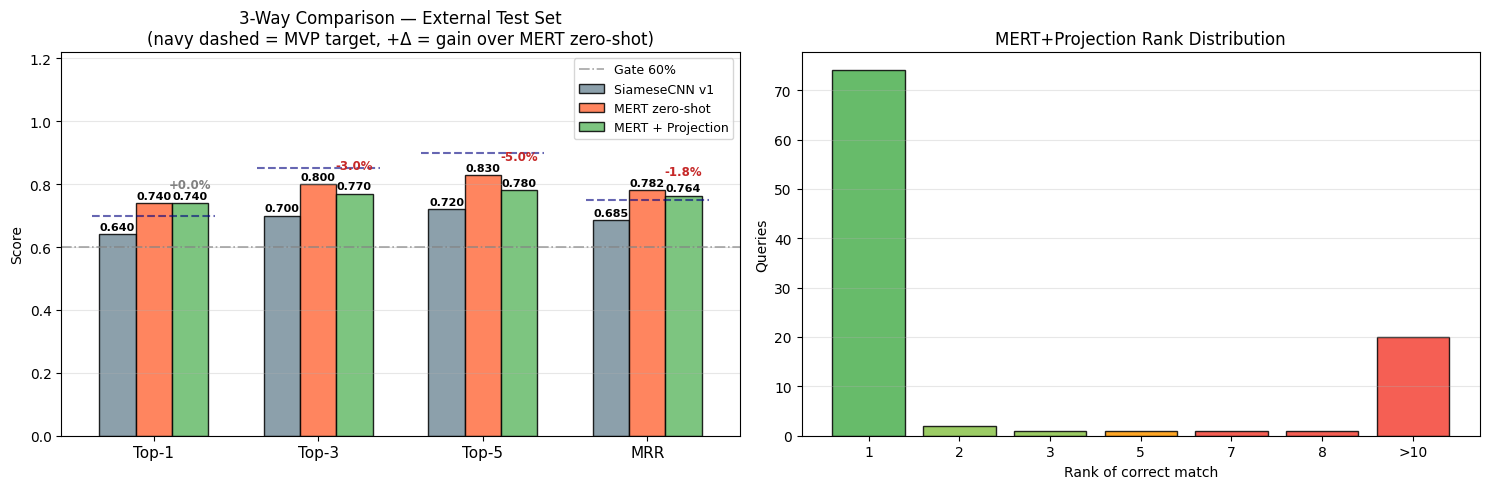

In [12]:
v1_vals  = [metrics_v1.get(k, 0) for k in metric_keys]
zs_vals  = [metrics_zs.get(k, 0) for k in metric_keys]
ft_vals  = [metrics_ft.get(k, 0) for k in metric_keys]

x = np.arange(len(metric_names)); w = 0.22
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── 3-way bar chart ──
b1 = axes[0].bar(x - w,   v1_vals, w, label='SiameseCNN v1', color='#78909C', alpha=0.85, edgecolor='black')
b2 = axes[0].bar(x,       zs_vals, w, label='MERT zero-shot', color='#FF7043', alpha=0.85, edgecolor='black')
b3 = axes[0].bar(x + w,   ft_vals, w, label='MERT + Projection', color='#66BB6A', alpha=0.85, edgecolor='black')
for i, mvp in enumerate(mvp_targets):
    axes[0].plot([i - 1.7*w, i + 1.7*w], [mvp, mvp], 'navy', ls='--', lw=1.5, alpha=0.6)
axes[0].axhline(0.60, color='gray', ls='-.', lw=1.2, alpha=0.7, label='Gate 60%')
for bar_group, vals in [(b1, v1_vals), (b2, zs_vals), (b3, ft_vals)]:
    for bar, val in zip(bar_group, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.007,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
# Δ from zero-shot to fine-tuned
for i, (zv, fv) in enumerate(zip(zs_vals, ft_vals)):
    d   = fv - zv
    col = '#2E7D32' if d > 0.005 else '#C62828' if d < -0.005 else 'gray'
    axes[0].text(i + w, max(zv, fv) + 0.048,
                 f'{d:+.1%}', ha='center', fontsize=8.5, color=col, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(metric_names, fontsize=11)
axes[0].set_ylim(0, 1.22); axes[0].set_ylabel('Score')
axes[0].set_title('3-Way Comparison — External Test Set\n'
                  '(navy dashed = MVP target, +Δ = gain over MERT zero-shot)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

# ── Rank distribution ──
rank_clip = np.clip(rank_pos, 1, 11)
ur, cnt   = np.unique(rank_clip, return_counts=True)
tick_lbl  = [str(r) if r <= 10 else '>10' for r in ur]
rc        = ['#4CAF50' if r == 1 else '#8BC34A' if r <= 3 else
             '#FF9800' if r <= 5 else '#F44336' for r in ur]
axes[1].bar(range(len(ur)), cnt, color=rc, edgecolor='black', alpha=0.85)
axes[1].set_xticks(range(len(ur))); axes[1].set_xticklabels(tick_lbl)
axes[1].set_xlabel('Rank of correct match'); axes[1].set_ylabel('Queries')
axes[1].set_title('MERT+Projection Rank Distribution')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

## 11. Per-Composer & Fur Elise

In [13]:
comp_stats = defaultdict(lambda: {'correct1':0,'correct3':0,'correct5':0,'rr':[],'n':0})
for i, meta in enumerate(query_meta):
    c, r = meta['composer'], rank_pos[i]
    comp_stats[c]['n'] += 1
    comp_stats[c]['rr'].append(1.0/r)
    if r<=1: comp_stats[c]['correct1']+=1
    if r<=3: comp_stats[c]['correct3']+=1
    if r<=5: comp_stats[c]['correct5']+=1

v1_comp = v1_res.get('per_composer', {})
zs_comp = json.load(open(MERT_EXT_RES))['per_composer'] if MERT_EXT_RES.exists() else {}
composers = sorted(comp_stats)

print(f'{"Composer":<12} {"N":>4} {"v1":>7} {"MERT ZS":>9} {"MERT+P":>8} {"Δ(ZS→P)":>9}')
print('─' * 55)
for c in composers:
    s    = comp_stats[c]; n = s['n']
    ft1  = s['correct1']/n
    v1t1 = v1_comp.get(c,{}).get('top1', float('nan'))
    zst1 = zs_comp.get(c,{}).get('top1', float('nan'))
    d    = ft1 - zst1 if not np.isnan(zst1) else float('nan')
    a    = ('▲' if d>0.005 else '▼' if d<-0.005 else '=') if not np.isnan(d) else '?'
    print(f'{c:<12} {n:>4} {v1t1:>7.1%} {zst1:>9.1%} {ft1:>8.1%} {d:>+8.1%} {a}')

# Fur Elise
elise_idx_c = stem_to_idx['elise.mid']
elise_rows  = []
for i, meta in enumerate(query_meta):
    if 'elise' not in meta['original'].lower(): continue
    fn = meta['filename']; r = rank_pos[i]
    k  = next((p[2:] for p in fn.replace('.mid','').split('_') if p.startswith('K-')), '?')
    t  = next((p[2:] for p in fn.replace('.mid','').split('_') if p.startswith('T-')), '?')
    sim = float(sim_matrix[i, elise_idx_c].item())
    elise_rows.append({'filename':fn,'key':k,'tempo':t,'rank':r,'rr':1/r,
                       'top1':r==1,'top5':r<=5,'sim':sim})
elise_df = pd.DataFrame(elise_rows)

zs_elise = json.load(open(MERT_EXT_RES))['fur_elise'] if MERT_EXT_RES.exists() else {}
v1_elise = v1_res.get('fur_elise', {})

print(f'\nFur Elise ({len(elise_df)} variations):')
print(f'  {"":12} {"v1 CNN":>9} {"MERT ZS":>9} {"MERT+Proj":>10}')
for metric, k1, k2, k3 in [
    ('Top-1', v1_elise.get('top1',0), zs_elise.get('top1',0), elise_df['top1'].mean()),
    ('Top-5', v1_elise.get('top5',0.333), zs_elise.get('top5',0), elise_df['top5'].mean()),
    ('MRR',   v1_elise.get('mrr',0.127),  zs_elise.get('mrr',0),  elise_df['rr'].mean())
]:
    d = k3 - k2; a = '▲' if d>0.005 else '▼' if d<-0.005 else '='
    print(f'  {metric:<12} {k1:>9.3f} {k2:>9.3f} {k3:>10.3f}  {d:+.3f} {a}')

# Per-variation table
print(f'\n{"Variation":<55} {"Key":>6} {"Rank":>5} {"Sim":>7} {"Hit@1":>6}')
print('─' * 80)
for _, row in elise_df.sort_values('rank').iterrows():
    print(f'{row["filename"]:<55} {row["key"]:>6} {int(row["rank"]):>5} '
          f'{row["sim"]:>7.4f} {"✓" if row["top1"] else "✗":>6}')

Composer        N      v1   MERT ZS   MERT+P   Δ(ZS→P)
───────────────────────────────────────────────────────
Albeniz        12   58.3%     83.3%    83.3%    +0.0% =
Beethoven      28   35.7%     46.4%    46.4%    -0.0% =
Chopin         46   89.1%     91.3%    93.5%    +2.2% ▲
Debussy         1  100.0%    100.0%   100.0%    +0.0% =
Liszt           4  100.0%    100.0%   100.0%    +0.0% =
Mozart          9   11.1%     44.4%    33.3%   -11.1% ▼

Fur Elise (12 variations):
                  v1 CNN   MERT ZS  MERT+Proj
  Top-1            0.000     0.083      0.083  +0.000 =
  Top-5            0.333     0.083      0.083  +0.000 =
  MRR              0.127     0.091      0.102  +0.012 ▲

Variation                                                  Key  Rank     Sim  Hit@1
────────────────────────────────────────────────────────────────────────────────
Fur Elise_Full_K-Amin_T-variable_bothhands.mid            Amin     1  0.9857      ✓
FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.mid          Ami

## 12. Save Results

In [14]:
failures = [(i, meta, per_q[i]) for i, meta in enumerate(query_meta) if rank_pos[i] > 5]

results = {
    'model':          'MERT-v1-95M + ProjectionHead (frozen encoder)',
    'mert_model':     MERT_MODEL,
    'projection':     {'hidden_dim': HIDDEN_DIM, 'embed_dim': EMBED_DIM,
                       'dropout': DROPOUT, 'params': proj_params},
    'training':       {'epochs': NUM_EPOCHS, 'lr': LR, 'margin': MARGIN,
                       'mining': MINING, 'batch_size': BATCH_SIZE},
    'corpus_size':    len(corpus_files),
    'n_queries':      n_queries,
    'metrics':        metrics_ft,
    'vs_zero_shot': {
        f'{k}_delta': round(metrics_ft.get(f'top{k}_accuracy',0) -
                            metrics_zs.get(f'top{k}_accuracy',0), 4)
        for k in K_VALUES
    },
    'vs_v1_cnn': {
        f'{k}_delta': round(metrics_ft.get(f'top{k}_accuracy',0) -
                            metrics_v1.get(f'top{k}_accuracy',0), 4)
        for k in K_VALUES
    },
    'per_composer': {
        c: {'n': s['n'],
             'top1': round(s['correct1']/s['n'], 4),
             'top3': round(s['correct3']/s['n'], 4),
             'top5': round(s['correct5']/s['n'], 4),
             'mrr':  round(float(np.mean(s['rr'])), 4)}
        for c, s in comp_stats.items()
    },
    'fur_elise': {
        'n':    len(elise_df),
        'top1': round(float(elise_df['top1'].mean()), 4),
        'top5': round(float(elise_df['top5'].mean()), 4),
        'mrr':  round(float(elise_df['rr'].mean()), 4),
        'keys_found': sorted(elise_df['key'].unique().tolist())
    },
    'failures_top5': [
        {'query': m['filename'], 'original': m['original'],
         'composer': m['composer'], 'rank': int(rank_pos[qi]),
         'top5_retrieved': per_q[qi]['top5']}
        for qi, m, _ in sorted(failures, key=lambda x: x[2]['rank'])
    ]
}

out = OUT_DIR / 'external_test_results.json'
with open(out, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Results saved → {out.resolve()}')

Results saved → /Users/manperumal/Desktop/2026/ML/ai_proj/checkpoints/mert_finetuned/external_test_results.json


## 13. Final Summary

In [15]:
gate_pass    = metrics_ft['top1_accuracy'] >= 0.60
mvp_pass     = (metrics_ft['top1_accuracy'] >= 0.70 and
                metrics_ft['top3_accuracy'] >= 0.85 and
                metrics_ft['mrr']           >= 0.75)
stretch_pass = (metrics_ft['top1_accuracy'] >= 0.85 and
                metrics_ft['mrr']           >= 0.85)

print('=' * 68)
print('MERT + PROJECTION HEAD — FINAL SUMMARY')
print('=' * 68)
print(f'  Architecture  : MERT (frozen 95M) + MLP ({proj_params:,} params)')
print(f'  Training time : {NUM_EPOCHS} epochs on {len(train_dataset)} chunks')
print(f'  Corpus        : {len(corpus_files)} files  |  Queries: {n_queries}')
print()
print(f'  {"Metric":<8} {"v1 CNN":>9} {"MERT ZS":>9} {"MERT+P":>9}  {"Δ(P-ZS)":>9}  MVP')
print('  ' + '─' * 58)
for name, k, mvp in zip(metric_names, metric_keys, mvp_targets):
    v1v  = metrics_v1.get(k, 0)
    zsv  = metrics_zs.get(k, 0)
    ftv  = metrics_ft.get(k, 0)
    d    = ftv - zsv
    a    = '▲' if d>0.005 else '▼' if d<-0.005 else '='
    st   = '✓' if ftv >= mvp else '✗'
    print(f'  {name:<8} {v1v:>9.4f} {zsv:>9.4f} {ftv:>9.4f}  {d:>+8.4f} {a}  {mvp:.0%} {st}')
print()
print(f'  Fur Elise Top-1 : v1={v1_elise.get("top1",0):.1%}  ZS={zs_elise.get("top1",0):.1%}  '
      f'Proj={elise_df["top1"].mean():.1%}')
print(f'  Fur Elise MRR   : v1={v1_elise.get("mrr",0):.3f}  ZS={zs_elise.get("mrr",0):.3f}  '
      f'Proj={elise_df["rr"].mean():.3f}')
print()
print(f'  Gate   (Top-1 ≥ 60%) : {"PASSED ✓" if gate_pass    else "FAILED ✗"}')
print(f'  MVP    (T1≥70,T3≥85,MRR≥0.75) : {"PASSED ✓" if mvp_pass    else "FAILED ✗"}')
print(f'  Stretch(T1≥85, MRR≥0.85)      : {"PASSED ✓" if stretch_pass else "FAILED ✗"}')
print()
if not mvp_pass:
    print('  Next steps to reach MVP:')
    print('   → Option 2: LoRA fine-tuning (unfreeze MERT attention layers)')
    print('   → Add pitch-shift augmentation (re-synthesize MIDI at ±3 semitones)')
    print('   → Increase MAX_AUDIO_S to 60s (more musical context per chunk)')
print('=' * 68)

MERT + PROJECTION HEAD — FINAL SUMMARY
  Architecture  : MERT (frozen 95M) + MLP (230,272 params)
  Training time : 30 epochs on 2162 chunks
  Corpus        : 292 files  |  Queries: 100

  Metric      v1 CNN   MERT ZS    MERT+P    Δ(P-ZS)  MVP
  ──────────────────────────────────────────────────────────
  Top-1       0.6400    0.7400    0.7400   +0.0000 =  70% ✓
  Top-3       0.7000    0.8000    0.7700   -0.0300 ▼  85% ✗
  Top-5       0.7200    0.8300    0.7800   -0.0500 ▼  90% ✗
  MRR         0.6846    0.7816    0.7636   -0.0181 ▼  75% ✓

  Fur Elise Top-1 : v1=0.0%  ZS=8.3%  Proj=8.3%
  Fur Elise MRR   : v1=0.127  ZS=0.091  Proj=0.102

  Gate   (Top-1 ≥ 60%) : PASSED ✓
  MVP    (T1≥70,T3≥85,MRR≥0.75) : FAILED ✗
  Stretch(T1≥85, MRR≥0.85)      : FAILED ✗

  Next steps to reach MVP:
   → Option 2: LoRA fine-tuning (unfreeze MERT attention layers)
   → Add pitch-shift augmentation (re-synthesize MIDI at ±3 semitones)
   → Increase MAX_AUDIO_S to 60s (more musical context per chunk)
